### Environment Setup 

In [6]:
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from sklearn.feature_extraction.text import CountVectorizer

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["font.size"] = 11

DATA_PATH = os.path.join("..", "dataset", "customer_support_tickets.csv")
print(f"Loading data from: {DATA_PATH}")
df = pd.read_csv(DATA_PATH)
print(f"Dataset Shape: {df.shape[0]} rows, {df.shape[1]} columns")

Loading data from: ../dataset/customer_support_tickets.csv
Dataset Shape: 8469 rows, 17 columns


---

### Schema Inspection & Missing Value Audit

,Data Type,Non-Null Count,Null Count,Null %,Unique Values
Ticket ID,int64,8469,0,0.00,8469
Customer Name,str,8469,0,0.00,8028
Customer Email,str,8469,0,0.00,8320
Customer Age,int64,8469,0,0.00,53
Customer Gender,str,8469,0,0.00,3
Product Purchased,str,8469,0,0.00,42
Date of Purchase,str,8469,0,0.00,730
Ticket Type,str,8469,0,0.00,5
Ticket Subject,str,8469,0,0.00,16
Ticket Description,str,8469,0,0.00,8077


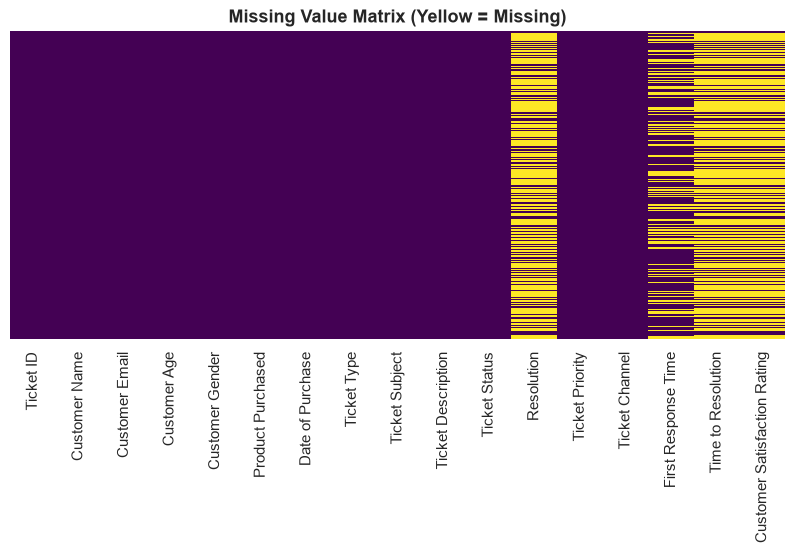

In [4]:
info_df = pd.DataFrame({
    "Data Type": df.dtypes,
    "Non-Null Count": df.notnull().sum(),
    "Null Count": df.isnull().sum(),
    "Null %": (df.isnull().sum() / len(df) * 100).round(2),
    "Unique Values": df.nunique()
})
display(info_df)

plt.figure(figsize=(10, 4))
sns.heatmap(df.isnull(), cbar=False, cmap="viridis", yticklabels=False)
plt.title("Missing Value Matrix (Yellow = Missing)", fontsize=13, weight="bold")
plt.show()

---

### Categorical and Target Distribution

/var/folders/16/22f61swd69g978whzzkl4r180000gn/T/ipykernel_50831/911709660.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y="Ticket Type", order=df["Ticket Type"].value_counts().index, ax=axes[0, 0], palette="Blues_r")
/var/folders/16/22f61swd69g978whzzkl4r180000gn/T/ipykernel_50831/911709660.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="Ticket Priority", order=["Low", "Medium", "High", "Critical"], ax=axes[0, 1], palette="Reds")
/var/folders/16/22f61swd69g978whzzkl4r180000gn/T/ipykernel_50831/911709660.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set 

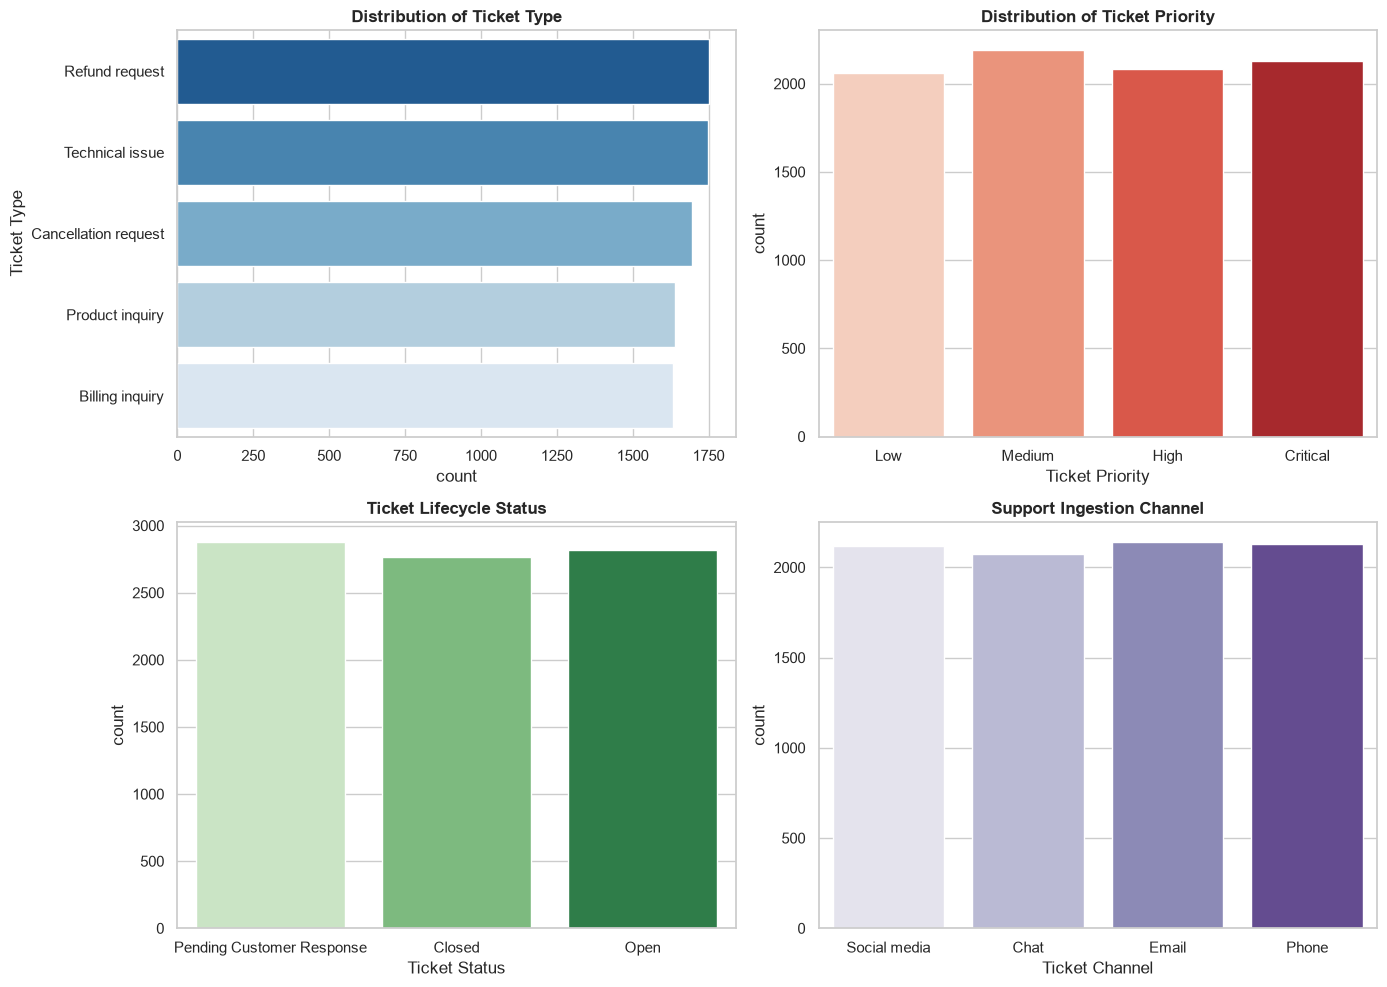

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Ticket Type (Target candidate 1)
sns.countplot(data=df, y="Ticket Type", order=df["Ticket Type"].value_counts().index, ax=axes[0, 0], palette="Blues_r")
axes[0, 0].set_title("Distribution of Ticket Type", weight="bold")

# Ticket Priority (Target candidate 2)
sns.countplot(data=df, x="Ticket Priority", order=["Low", "Medium", "High", "Critical"], ax=axes[0, 1], palette="Reds")
axes[0, 1].set_title("Distribution of Ticket Priority", weight="bold")

# Ticket Status
sns.countplot(data=df, x="Ticket Status", ax=axes[1, 0], palette="Greens")
axes[1, 0].set_title("Ticket Lifecycle Status", weight="bold")

# Ingestion Channel
sns.countplot(data=df, x="Ticket Channel", ax=axes[1, 1], palette="Purples")
axes[1, 1].set_title("Support Ingestion Channel", weight="bold")

plt.tight_layout()
plt.show()

---

### Critical Analysis - Statistical Independence Check

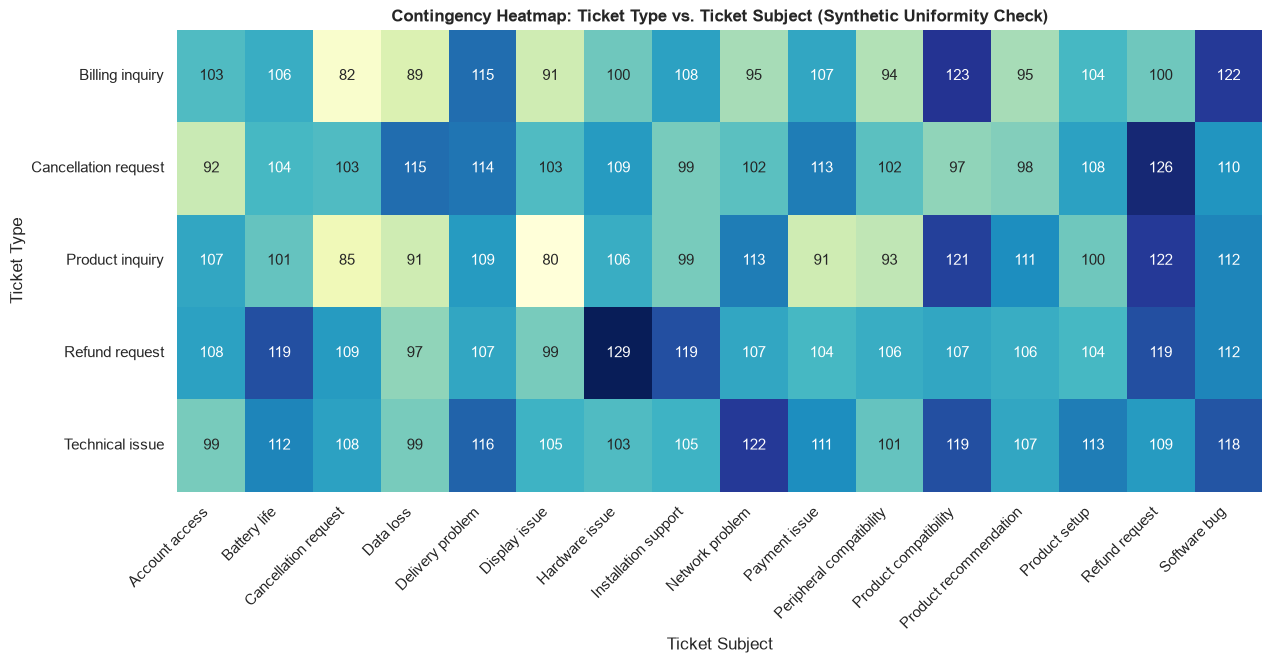

Chi-Square Statistic: 39.5715
p-value: 0.9807 (p > 0.05 indicates features are statistically independent)


In [8]:
# Cross-tabulate Ticket Subject across Ticket Type
cross_tab = pd.crosstab(df["Ticket Type"], df["Ticket Subject"])
plt.figure(figsize=(14, 6))
sns.heatmap(cross_tab, annot=True, fmt="d", cmap="YlGnBu", cbar=False)
plt.title("Contingency Heatmap: Ticket Type vs. Ticket Subject (Synthetic Uniformity Check)", weight="bold")
plt.xlabel("Ticket Subject")
plt.ylabel("Ticket Type")
plt.xticks(rotation=45, ha="right")
plt.show()

# Chi-Square Test of Independence
from scipy.stats import chi2_contingency
chi2, p, dof, expected = chi2_contingency(cross_tab)
print(f"Chi-Square Statistic: {chi2:.4f}")
print(f"p-value: {p:.4f} (p > 0.05 indicates features are statistically independent)")

---

### Text Length and Token Distribution Analysis 

/var/folders/16/22f61swd69g978whzzkl4r180000gn/T/ipykernel_50831/3457330439.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Ticket Type", y="desc_word_count", ax=axes[1], palette="Set2")
/var/folders/16/22f61swd69g978whzzkl4r180000gn/T/ipykernel_50831/3457330439.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=30)


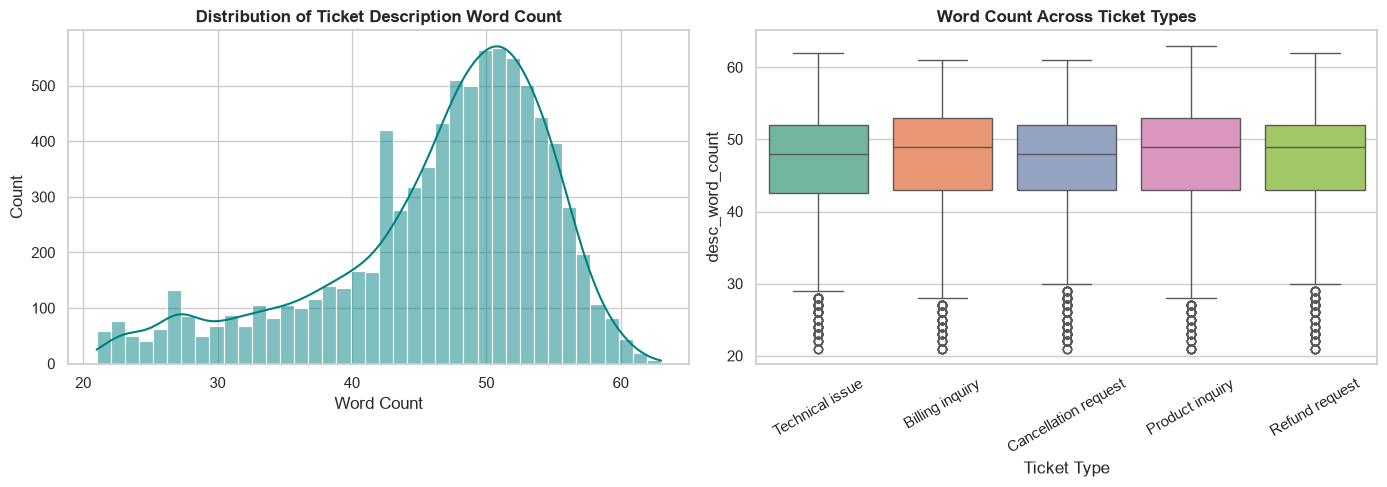

Summary Statistics for Description Word Counts:


count    8469.000000
mean       46.467352
std         8.461730
min        21.000000
25%        43.000000
50%        49.000000
75%        52.000000
max        63.000000
Name: desc_word_count, dtype: float64

In [10]:
# Computing text length metrics
df["desc_char_len"] = df["Ticket Description"].str.len()
df["desc_word_count"] = df["Ticket Description"].apply(lambda x: len(str(x).split()))
df["subject_word_count"] = df["Ticket Subject"].apply(lambda x: len(str(x).split()))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df["desc_word_count"], bins=40, kde=True, ax=axes[0], color="teal")
axes[0].set_title("Distribution of Ticket Description Word Count", weight="bold")
axes[0].set_xlabel("Word Count")

sns.boxplot(data=df, x="Ticket Type", y="desc_word_count", ax=axes[1], palette="Set2")
axes[1].set_title("Word Count Across Ticket Types", weight="bold")
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=30)

plt.tight_layout()
plt.show()

print("Summary Statistics for Description Word Counts:")
display(df["desc_word_count"].describe())

---

### Lexical Inspection and Template Artifact Extraction

Top Placeholder Artifacts Found in Text:
Ticket Description
{product_purchased}     13719
{error_message}           472
{product_id}               48
{product_name}             32
{Product_purchased}        18
{product}                  11
{{product_purchased}        8
{name}                      8
{product_price}             8
{Product}                   6
Name: count, dtype: int64


/var/folders/16/22f61swd69g978whzzkl4r180000gn/T/ipykernel_50831/3282276252.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=ngram_counts, x="Frequency", y="Bigram", palette="viridis")


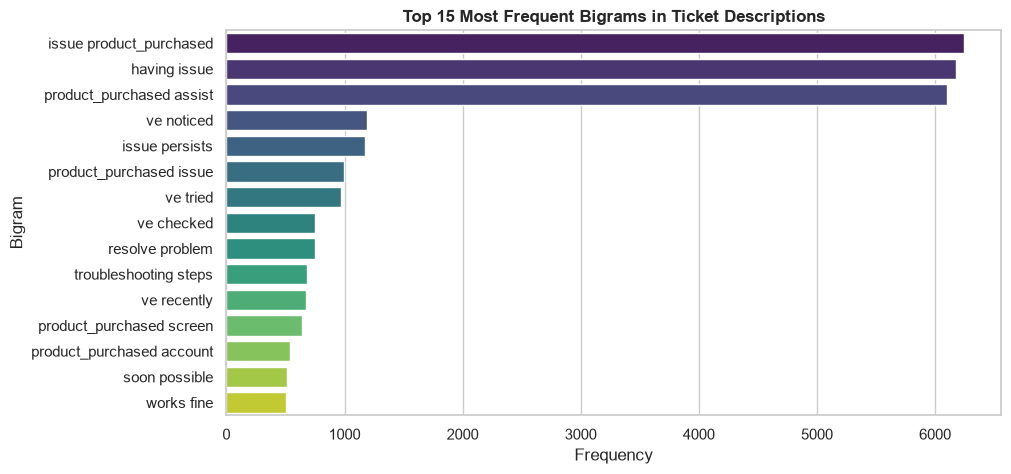

In [11]:
# Detect boilerplate placeholders in the text
placeholder_pattern = r"\{.*?\}"
detected_placeholders = df["Ticket Description"].str.findall(placeholder_pattern).explode().dropna()
print("Top Placeholder Artifacts Found in Text:")
print(detected_placeholders.value_counts().head(10))

# Top 20 N-Grams across the raw corpus
vec = CountVectorizer(stop_words="english", ngram_range=(2, 2), max_features=15)
ngrams = vec.fit_transform(df["Ticket Description"])
ngram_counts = pd.DataFrame({
    "Bigram": vec.get_feature_names_out(),
    "Frequency": ngrams.toarray().sum(axis=0)
}).sort_values(by="Frequency", ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(data=ngram_counts, x="Frequency", y="Bigram", palette="viridis")
plt.title("Top 15 Most Frequent Bigrams in Ticket Descriptions", weight="bold")
plt.show()

Key Takeaways from Notebook 1 (EDA):
1. Target Distribution: Classes ('Billing inquiry', 'Technical issue', 'Cancellation request', etc.) are perfectly balanced (~1,650 to ~1,750 samples each).
2. Data Quality & Artifacts: The text contains synthetic templated tokens like '{product_purchased}' and generic non-sequitur sentences.
3. Label Independence: The Kaggle target labels are statistically uncorrelated with the text templates (Chi-square p > 0.05).
4. Feature Strategy for Notebook 2:
   - Clean placeholders and noise tokens.
   - Combine 'Ticket Subject' + 'Product Purchased' + 'Ticket Description' into a unified text feature.
   - Implement TF-IDF vectorization and domain keyword enrichment for Notebook 3 model training.

`NOTE This to be added in the report - analysis of this dataset`